# DS2002 Capstone — EV Charging Station Analytics

**Team Number:** `team-18`

**Team Members:**
- Jonathan Lam (rgm6yp)
- Wyatt Schmidt (rrq3jp)

**Date:** 2026-04-02

---

## Cloud Setup

Authenticate to GCS, download raw data, and verify your team folder.

In [1]:
# Install the GCS library (run once)
!pip install google-cloud-storage -q

In [2]:
import os
import json
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import numpy as np

from google.colab import auth
auth.authenticate_user()

from google.cloud import storage
client = storage.Client(project="ds2002-492012")
bucket = client.bucket("ds2002-capstone-sp26-v2")
print("GCS authentication successful.")

GCS authentication successful.


In [3]:
# Download raw data from GCS
TEAM = "team-18"  # <-- change to your team number

files = [
    "raw-data/charging_sessions.csv",
    "raw-data/station_locations.csv",
    "raw-data/vehicle_types.csv",
    "raw-data/grid_operators.csv",
    "raw-data/energy_and_demand.db",
]

os.makedirs("data", exist_ok=True)
for f in files:
    blob = bucket.blob(f)
    local = os.path.join("data", os.path.basename(f))
    blob.download_to_filename(local)
    print(f"Downloaded {f}")

Downloaded raw-data/charging_sessions.csv
Downloaded raw-data/station_locations.csv
Downloaded raw-data/vehicle_types.csv
Downloaded raw-data/grid_operators.csv
Downloaded raw-data/energy_and_demand.db


## Data Loading

In [4]:
sessions = pd.read_csv("data/charging_sessions.csv")
stations = pd.read_csv("data/station_locations.csv")
vehicles = pd.read_csv("data/vehicle_types.csv")
operators = pd.read_csv("data/grid_operators.csv")

conn = sqlite3.connect("data/energy_and_demand.db")
demand = pd.read_sql("SELECT * FROM daily_demand_summary", conn)
grid = pd.read_sql("SELECT * FROM grid_capacity_levels", conn)
conn.close()

print(f"Sessions: {sessions.shape}")
print(f"Stations: {stations.shape}")
print(f"Vehicles: {vehicles.shape}")
print(f"Operators: {operators.shape}")
print(f"Demand:   {demand.shape}")
print(f"Grid:     {grid.shape}")

Sessions: (27451, 11)
Stations: (21, 8)
Vehicles: (42, 6)
Operators: (5, 7)
Demand:   (6570, 7)
Grid:     (1825, 6)


## Data Exploration

Inspect each dataset before cleaning.

In [5]:
# Your exploration code here
# .shape, .dtypes, .info(), .describe(), .isnull().sum()

print("Sessions Dataset:")
print("shape: \n", sessions.shape)
print()
print("dtypes: \n", sessions.dtypes)
print()
print("info: \n", sessions.info())
print()
print("describe: \n", sessions.describe())
print()
print("null count: \n", sessions.isnull().sum())
sessions

Sessions Dataset:
shape: 
 (27451, 11)

dtypes: 
 session_id         object
station_id         object
vehicle_id         object
session_start      object
session_end        object
kwh_delivered     float64
session_type       object
cost_usd           object
payment_method     object
connector_used     object
user_id            object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27451 entries, 0 to 27450
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   session_id      27451 non-null  object 
 1   station_id      27451 non-null  object 
 2   vehicle_id      27374 non-null  object 
 3   session_start   27451 non-null  object 
 4   session_end     27451 non-null  object 
 5   kwh_delivered   27361 non-null  float64
 6   session_type    27451 non-null  object 
 7   cost_usd        27384 non-null  object 
 8   payment_method  27451 non-null  object 
 9   connector_used  27385 non-null  object 


,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id
0,SES-005321,STN-013,VH-008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,Level 1,0.53,credit card,J1772,U-4469
1,SES-021125,STN-012,VH-005,10-19-2025 17:10:08,10-19-2025 18:40:08,13.69,DC Fast Charge,1.92,debit_card,CHAdeMO,U-4434
2,SES-026798,STN-007,VEH#0005,12/30/2025 07:30,12/30/2025 08:21,9.62,Level 1,3.56,Credit Card,CCS,U-6845
3,SES-008299,STN-006,VH-005,04-28-2025 02:35:41,04-28-2025 04:52:41,70.99,DC Fast Charge,26.27,app_wallet,Tesla Supercharger,U-7854
4,SES-018503,STN-012,VH-011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,Level 2,2.84,credit card,CCS,U-2903
...,...,...,...,...,...,...,...,...,...,...,...
27446,SES-000851,STN-002,V_bmw_ix,2025-01-13 17:02:56,2025-01-13 19:22:56,60.21,DC Fast Charge,$9.03,debit_card,CHAdeMO,U-3483
27447,SES-024197,STN-014,VH-001,11-30-2025 12:33:34,11-30-2025 12:44:34,72.06,DC Fast Charge,$17.29,RFID,CHAdeMO,U-8563
27448,SES-019360,STN-010,VH-010,2025/09/26 17:16,2025/09/26 18:25,38.54,Level 2,4.24,Credit Card,CCS,U-2209
27449,SES-016268,STN-004,VH-004,14-Aug-2025 16:57:43,14-Aug-2025 19:54:43,26.59,Level 2,8.77,app_wallet,CCS,U-2823


In [6]:
print("Stations Dataset:")
print("shape: \n", stations.shape)
print()
print("dtypes: \n", stations.dtypes)
print()
print("info: \n", stations.info())
print()
print("describe: \n", stations.describe())
print()
print("null count: \n", stations.isnull().sum())
stations

Stations Dataset:
shape: 
 (21, 8)

dtypes: 
 station_id       object
station_name     object
city             object
state            object
zip_code          int64
latitude        float64
longitude       float64
region           object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_id    21 non-null     object 
 1   station_name  21 non-null     object 
 2   city          21 non-null     object 
 3   state         21 non-null     object 
 4   zip_code      21 non-null     int64  
 5   latitude      20 non-null     float64
 6   longitude     20 non-null     float64
 7   region        20 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.4+ KB
info: 
 None

describe: 
            zip_code   latitude  longitude
count     21.000000  20.000000  20.000000
mean   22907.666667  38.042160 -78.483870
s

,station_id,station_name,city,state,zip_code,latitude,longitude,region
0,STN-001,Downtown Charging Hub,Charlottesville,VA,22902,38.0293,-78.4767,Central
1,STN-002,University Ave Station,Charlottesville,VA,22903,38.0336,-78.5080,Central
2,STN-003,Pantops Charging Plaza,Charlottesville,VA,22911,38.0280,-78.4490,East
3,STN-004,Barracks Road Station,Charlottesville,VA,22903,38.0440,-78.5070,West
4,STN-005,Rivanna Station,Charlottesville,Virginia,22911,38.0520,-78.4430,East
5,STN-006,5th Street Hub,Charlottesville,VA,22902,38.0200,-78.4880,Central
6,STN-007,Rio Road Charging,Charlottesville,VA,22901,38.0700,-78.4800,North
7,STN-008,Hydraulic Rd Station,Charlottesville,VA,22901,38.0560,-78.4990,North
8,STN-009,Seminole Trail Plaza,Charlottesville,VA,22901,38.0800,-78.4850,North
9,STN-010,Avon Street Hub,Charlottesville,virginia,22902,38.0100,-78.4750,South


In [7]:
print("Vehicles Dataset:")
print("shape: \n", vehicles.shape)
print()
print("dtypes: \n", vehicles.dtypes)
print()
print("info: \n", vehicles.info())
print()
print("describe: \n", vehicles.describe())
print()
print("null count: \n", vehicles.isnull().sum())
vehicles

Vehicles Dataset:
shape: 
 (42, 6)

dtypes: 
 vehicle_id        object
vehicle_name      object
vehicle_class     object
connector_type    object
battery_kwh       object
manufacturer      object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   vehicle_id      42 non-null     object
 1   vehicle_name    42 non-null     object
 2   vehicle_class   42 non-null     object
 3   connector_type  42 non-null     object
 4   battery_kwh     27 non-null     object
 5   manufacturer    41 non-null     object
dtypes: object(6)
memory usage: 2.1+ KB
info: 
 None

describe: 
        vehicle_id   vehicle_name vehicle_class connector_type battery_kwh  \
count          42             42            42             42          27   
unique         42             42            11              4          12   
top        VH-001  Tesla Model 3      

,vehicle_id,vehicle_name,vehicle_class,connector_type,battery_kwh,manufacturer
0,VH-001,Tesla Model 3,Sedan,CCS,75.0,Tesla
1,VEH#0001,TESLA MODEL 3,SEDAN,CCS,NaN,TESLA
2,V_tesla_model_3,tesla model 3,sedan,ccs,75.0,tesla
3,VH-002,Tesla Model Y,SUV,CCS,NaN,Tesla
4,VEH#0002,TESLA MODEL Y,SUV,CCS,NaN,TESLA
5,V_tesla_model_y,tesla model y,suv,ccs,75.0,tesla
6,VH-003,Tesla Model S,Sedan,CCS,100.0,Tesla
7,VEH#0003,TESLA MODEL S,suv,CCS,NaN,TESLA
8,V_tesla_model_s,tesla model s,sedan,ccs,100.0,tesla
9,VH-004,Chevrolet Bolt EV,Hatchback,CCS,65.0,Chevrolet


In [8]:
print("Operators Dataset:")
print("shape: \n", operators.shape)
print()
print("dtypes: \n", operators.dtypes)
print()
print("info: \n", operators.info())
print()
print("describe: \n", operators.describe())
print()
print("null count: \n", operators.isnull().sum())
operators

Operators Dataset:
shape: 
 (5, 7)

dtypes: 
 operator_id               object
operator_name             object
city                      object
state                     object
avg_daily_capacity_mw      int64
peak_capacity_mw          object
cost_per_kwh             float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   operator_id            5 non-null      object 
 1   operator_name          5 non-null      object 
 2   city                   5 non-null      object 
 3   state                  5 non-null      object 
 4   avg_daily_capacity_mw  5 non-null      int64  
 5   peak_capacity_mw       5 non-null      object 
 6   cost_per_kwh           4 non-null      float64
dtypes: float64(1), int64(1), object(5)
memory usage: 412.0+ bytes
info: 
 None

describe: 
        avg_daily_capacity_mw  cost_per_kwh
coun

,operator_id,operator_name,city,state,avg_daily_capacity_mw,peak_capacity_mw,cost_per_kwh
0,GO-CVL,Charlottesville Energy Cooperative,Charlottesville,VA,120,240,0.12
1,GO-DOM,Dominion Energy Virginia,Richmond,VA,450,800,0.11
2,GO-APC,Appalachian Power,Roanoke,VA,300,~550,0.13
3,GO-REC,Rappahannock Electric,Fredericksburg,VA,200,400,0.14
4,GO-NRG,Northern Virginia Electric,Fairfax,VA,380,700,NaN


In [9]:
print("Demand Dataset:")
print("shape: \n", demand.shape)
print()
print("dtypes: \n", demand.dtypes)
print()
print("info: \n", demand.info())
print()
print("describe: \n", demand.describe())
print()
print("null count: \n", demand.isnull().sum())
demand

Demand Dataset:
shape: 
 (6570, 7)

dtypes: 
 date                         object
station_id                   object
total_sessions                int64
total_kwh_delivered         float64
avg_session_duration_min    float64
peak_hour                     int64
revenue_usd                 float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6570 entries, 0 to 6569
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      6570 non-null   object 
 1   station_id                6570 non-null   object 
 2   total_sessions            6570 non-null   int64  
 3   total_kwh_delivered       6570 non-null   float64
 4   avg_session_duration_min  6570 non-null   float64
 5   peak_hour                 6570 non-null   int64  
 6   revenue_usd               6570 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 359.4+ KB
info: 
 None

describe

,date,station_id,total_sessions,total_kwh_delivered,avg_session_duration_min,peak_hour,revenue_usd
0,2025-01-01,STN-001,5,126.31,61.5,9,32.08
1,2025-01-01,STN-002,6,212.06,69.0,13,29.18
2,2025-01-01,STN-003,3,77.90,85.8,14,18.57
3,2025-01-01,STN-004,7,274.85,65.6,22,94.37
4,2025-01-01,STN-005,8,154.57,31.5,9,36.30
...,...,...,...,...,...,...,...
6565,2025-12-31,STN-014,14,357.30,79.4,21,71.11
6566,2025-12-31,STN-015,8,124.43,81.4,8,47.13
6567,2025-12-31,STN-016,6,121.19,30.1,22,39.42
6568,2025-12-31,STN-017,10,376.41,71.7,9,94.45


In [10]:
print("Grid Dataset:")
print("shape: \n", grid.shape)
print()
print("dtypes: \n", grid.dtypes)
print()
print("info: \n", grid.info())
print()
print("describe: \n", grid.describe())
print()
print("null count: \n", grid.isnull().sum())
grid

Grid Dataset:
shape: 
 (1825, 6)

dtypes: 
 date                      object
operator_id               object
available_capacity_mw    float64
load_pct                 float64
outage_flag                int64
temperature_high_f       float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1825 non-null   object 
 1   operator_id            1825 non-null   object 
 2   available_capacity_mw  1825 non-null   float64
 3   load_pct               1825 non-null   float64
 4   outage_flag            1825 non-null   int64  
 5   temperature_high_f     1825 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 85.7+ KB
info: 
 None

describe: 
        available_capacity_mw     load_pct  outage_flag  temperature_high_f
count            1825.000000  1825.000000  1825.000000   

,date,operator_id,available_capacity_mw,load_pct,outage_flag,temperature_high_f
0,2025-01-01,GO-CVL,239.2,50.7,0,46.5
1,2025-01-01,GO-DOM,186.6,51.1,1,26.0
2,2025-01-01,GO-APC,459.4,52.9,0,27.1
3,2025-01-01,GO-REC,311.0,51.4,0,33.5
4,2025-01-01,GO-NRG,290.6,50.8,0,46.2
...,...,...,...,...,...,...
1820,2025-12-31,GO-CVL,162.5,78.0,0,42.8
1821,2025-12-31,GO-DOM,394.3,54.9,0,27.6
1822,2025-12-31,GO-APC,257.2,57.8,0,43.8
1823,2025-12-31,GO-REC,161.8,63.2,0,48.1


## Data Cleaning Pipeline

Document every cleaning step. Show before and after.

In [11]:
# helper functions
def profile_df(df, name="df"):
    print(f"\n{name} overview")
    print("Shape:", df.shape)
    print("\nDtypes:\n", df.dtypes)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nSample:\n", df.head(3))

def standardize_id(col):
    return (
        col.astype(str)
           .str.strip()
           .str.upper()
           .str.replace(r"\s+", "_", regex=True)
    )

In [12]:
vehicle_mapping = {
    "VH-001": "VH-001",
    "VEH#0001": "VH-001",
    "V_TESLA_MODEL_3": "VH-001",

    "VH-002": "VH-002",
    "VEH#0002": "VH-002",
    "V_TESLA_MODEL_Y": "VH-002",

    "VH-003": "VH-003",
    "VEH#0003": "VH-003",
    "V_TESLA_MODEL_S": "VH-003",

    "VH-004": "VH-004",
    "VEH#0004": "VH-004",
    "V_CHEVROLET_BOLT_EV": "VH-004",

    "VH-005": "VH-005",
    "VEH#0005": "VH-005",
    "V_CHEVROLET_BOLT_EUV": "VH-005",

    "VH-006": "VH-006",
    "VEH#0006": "VH-006",
    "V_FORD_MUSTANG_MACH-E": "VH-006",

    "VH-007": "VH-007",
    "VEH#0007": "VH-007",
    "V_FORD_F-150_LIGHTNING": "VH-007",

    "VH-008": "VH-008",
    "VEH#0008": "VH-008",
    "V_HYUNDAI_IONIQ_5": "VH-008",

    "VH-009": "VH-009",
    "VEH#0009": "VH-009",
    "V_KIA_EV6": "VH-009",

    "VH-010": "VH-010",
    "VEH#0010": "VH-010",
    "V_NISSAN_LEAF": "VH-010",

    "VH-011": "VH-011",
    "VEH#0011": "VH-011",
    "V_BMW_IX": "VH-011",

    "VH-012": "VH-012",
    "VEH#0012": "VH-012",
    "V_RIVIAN_R1T": "VH-012",

    "VH-013": "VH-013",
    "VEH#0013": "VH-013",
    "V_VOLKSWAGEN_ID.4": "VH-013",

    "VH-014": "VH-014",
    "VEH#0014": "VH-014",
    "V_LUCID_AIR": "VH-014"
}

station_mapping = {
    "STN16": "STN-016",
    "STN08": "STN-008",
    "STN09": "STN-009",
    "STN02": "STN-002",
    "STN01": "STN-001",
    "STN10": "STN-010",
    "STN06": "STN-006",
    "STN04": "STN-004",
    "STN15": "STN-015",
    "STN14": "STN-014",
    "STN13": "STN-013",
    "STN17": "STN-017",
    "STN07": "STN-007",
    "STN05": "STN-005",
    "STN11": "STN-011",
    "STN03": "STN-003",
    "STN18": "STN-018",
    "STN12": "STN-012"
}

# helper function to address the data quality issues in the sessions table
def clean_sessions(df):
    df = df.copy()

    df["vehicle_id"] = (
        df["vehicle_id"]
        .astype(str)
        .str.upper()
        .str.strip()
        .replace(vehicle_mapping)
    )

    df["station_id"] = (
        df["station_id"]
        .astype(str)
        .str.upper()
        .str.strip()
        .replace(station_mapping)
    )

    df["session_start"] = pd.to_datetime(
        df["session_start"],
        format="mixed",
        errors="coerce"
    )

    df["session_end"] = pd.to_datetime(
        df["session_end"],
        format="mixed",
        errors="coerce"
    )

    df["cost_usd"] = (
        df["cost_usd"]
        .astype(str)
        .str.replace("$", "", regex=False)
    )
    df["cost_usd"] = pd.to_numeric(df["cost_usd"], errors="coerce")

    df["kwh_delivered"] = df["kwh_delivered"].fillna(df["kwh_delivered"].median())
    df["kwh_delivered"] = df["kwh_delivered"].abs()

    df["connector_used"] = df["connector_used"].fillna("UNKNOWN")
    df["connector_used"] = df["connector_used"].astype(str).str.upper().str.strip()

    df["cost_usd"] = df["cost_usd"].fillna(df["cost_usd"].median())

    df["payment_method"] = df["payment_method"].replace("credit card", "credit_card")
    df["payment_method"] = df["payment_method"].replace("Credit Card", "credit_card")
    df["payment_method"] = df["payment_method"].replace("CREDIT_CARD", "credit_card")
    df["payment_method"] = df["payment_method"].replace("Google Pay", "google_pay")
    df["payment_method"] = df["payment_method"].replace("Apple Pay", "apple_pay")
    df["payment_method"] = df["payment_method"].replace("RFID", "rfid")
    df["payment_method"] = df["payment_method"].replace("RFID", "rfid")

    return df

In [13]:
profile_df(sessions, "Sessions before:")
sessions_clean = clean_sessions(sessions)
profile_df(sessions_clean, "Sessions after:")


Sessions before: overview
Shape: (27451, 11)

Dtypes:
 session_id         object
station_id         object
vehicle_id         object
session_start      object
session_end        object
kwh_delivered     float64
session_type       object
cost_usd           object
payment_method     object
connector_used     object
user_id            object
dtype: object

Missing values:
 session_id         0
station_id         0
vehicle_id        77
session_start      0
session_end        0
kwh_delivered     90
session_type       0
cost_usd          67
payment_method     0
connector_used    66
user_id            0
dtype: int64

Sample:
    session_id station_id vehicle_id        session_start          session_end  \
0  SES-005321    STN-013     VH-008  2025-03-16 17:06:25  2025-03-16 18:30:25   
1  SES-021125    STN-012     VH-005  10-19-2025 17:10:08  10-19-2025 18:40:08   
2  SES-026798    STN-007   VEH#0005     12/30/2025 07:30     12/30/2025 08:21   

   kwh_delivered    session_type cost_usd payme

In [14]:
sessions_clean

,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id
0,SES-005321,STN-013,VH-008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,Level 1,0.53,credit_card,J1772,U-4469
1,SES-021125,STN-012,VH-005,2025-10-19 17:10:08,2025-10-19 18:40:08,13.69,DC Fast Charge,1.92,debit_card,CHADEMO,U-4434
2,SES-026798,STN-007,VH-005,2025-12-30 07:30:00,2025-12-30 08:21:00,9.62,Level 1,3.56,credit_card,CCS,U-6845
3,SES-008299,STN-006,VH-005,2025-04-28 02:35:41,2025-04-28 04:52:41,70.99,DC Fast Charge,26.27,app_wallet,TESLA SUPERCHARGER,U-7854
4,SES-018503,STN-012,VH-011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,Level 2,2.84,credit_card,CCS,U-2903
...,...,...,...,...,...,...,...,...,...,...,...
27446,SES-000851,STN-002,VH-011,2025-01-13 17:02:56,2025-01-13 19:22:56,60.21,DC Fast Charge,9.03,debit_card,CHADEMO,U-3483
27447,SES-024197,STN-014,VH-001,2025-11-30 12:33:34,2025-11-30 12:44:34,72.06,DC Fast Charge,17.29,rfid,CHADEMO,U-8563
27448,SES-019360,STN-010,VH-010,2025-09-26 17:16:00,2025-09-26 18:25:00,38.54,Level 2,4.24,credit_card,CCS,U-2209
27449,SES-016268,STN-004,VH-004,2025-08-14 16:57:43,2025-08-14 19:54:43,26.59,Level 2,8.77,app_wallet,CCS,U-2823


In [15]:
station_mapping = {
    "STN001": "STN-001",
    "STN01":  "STN-001",
    "STN002": "STN-002",
    "STN02":  "STN-002",
    "STN003": "STN-003",
    "STN03":  "STN-003",
    "STN004": "STN-004",
    "STN04":  "STN-004",
    "STN005": "STN-005",
    "STN05":  "STN-005",
    "STN006": "STN-006",
    "STN06":  "STN-006",
    "STN007": "STN-007",
    "STN07":  "STN-007",
    "STN_007": "STN-007",
    "STN008": "STN-008",
    "STN08":  "STN-008",
    "STN009": "STN-009",
    "STN09":  "STN-009",
    "STN010": "STN-010",
    "STN10":  "STN-010"
}

# helper function to clean stations
def clean_stations(df):
    df = df.copy()

    df["station_id"] = standardize_id(df["station_id"])
    df["station_id"] = df["station_id"].replace(station_mapping)
    df["state"] = df["state"].astype(str).str.upper().str.strip()
    df["state"] = df["state"].replace("VIRGINIA", "VA")
    df["state"] = df["state"].replace("VA.", "VA")

    # fix coordinates
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

    # region cleanup
    df["region"] = df["region"].fillna("UNKNOWN").str.upper()



    return df

In [16]:
profile_df(stations, "Stations before:")
stations_clean = clean_stations(stations)
stations_clean = stations_clean.drop_duplicates(subset=["station_id"])
profile_df(stations_clean, "Stations after:")

stations_clean


Stations before: overview
Shape: (21, 8)

Dtypes:
 station_id       object
station_name     object
city             object
state            object
zip_code          int64
latitude        float64
longitude       float64
region           object
dtype: object

Missing values:
 station_id      0
station_name    0
city            0
state           0
zip_code        0
latitude        1
longitude       1
region          1
dtype: int64

Sample:
   station_id            station_name             city state  zip_code  \
0    STN-001   Downtown Charging Hub  Charlottesville    VA     22902   
1    STN-002  University Ave Station  Charlottesville    VA     22903   
2    STN-003  Pantops Charging Plaza  Charlottesville    VA     22911   

   latitude  longitude   region  
0   38.0293   -78.4767  Central  
1   38.0336   -78.5080  Central  
2   38.0280   -78.4490     East  

Stations after: overview
Shape: (19, 8)

Dtypes:
 station_id       object
station_name     object
city             object
state

,station_id,station_name,city,state,zip_code,latitude,longitude,region
0,STN-001,Downtown Charging Hub,Charlottesville,VA,22902,38.0293,-78.4767,CENTRAL
1,STN-002,University Ave Station,Charlottesville,VA,22903,38.0336,-78.5080,CENTRAL
2,STN-003,Pantops Charging Plaza,Charlottesville,VA,22911,38.0280,-78.4490,EAST
3,STN-004,Barracks Road Station,Charlottesville,VA,22903,38.0440,-78.5070,WEST
4,STN-005,Rivanna Station,Charlottesville,VA,22911,38.0520,-78.4430,EAST
5,STN-006,5th Street Hub,Charlottesville,VA,22902,38.0200,-78.4880,CENTRAL
6,STN-007,Rio Road Charging,Charlottesville,VA,22901,38.0700,-78.4800,NORTH
7,STN-008,Hydraulic Rd Station,Charlottesville,VA,22901,38.0560,-78.4990,NORTH
8,STN-009,Seminole Trail Plaza,Charlottesville,VA,22901,38.0800,-78.4850,NORTH
9,STN-010,Avon Street Hub,Charlottesville,VA,22902,38.0100,-78.4750,SOUTH


In [17]:
def clean_vehicles(df):
    df = df.copy()

    df["vehicle_id"] = (
        df["vehicle_id"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    df["battery_kwh"] = pd.to_numeric(df["battery_kwh"], errors="coerce")

    # fill missing battery_kwh using vehicle_name aliases
    df["battery_kwh"] = df.groupby("vehicle_name")["battery_kwh"].transform(
        lambda x: x.fillna(x.dropna().iloc[0] if x.notna().any() else np.nan)
    )

    for col in ["vehicle_name", "vehicle_class", "connector_type", "manufacturer"]:
        df[col] = df[col].astype(str).str.strip().str.title()

    # fix bad "Nan" strings
    df["manufacturer"] = df["manufacturer"].replace("Nan", np.nan)

    df["vehicle_id"] = df["vehicle_id"].replace(vehicle_mapping)

    df["manufacturer"] = df["manufacturer"].fillna("Unknown")

    df_clean = (
        df.sort_values("vehicle_id")
          .drop_duplicates(subset=["vehicle_id"], keep="first")
          .reset_index(drop=True)
    )

    return df_clean

In [18]:
profile_df(vehicles, "Vehicles before:")
vehicles_clean = clean_vehicles(vehicles)
profile_df(vehicles_clean, "Vehicles after:")

vehicles_clean


Vehicles before: overview
Shape: (42, 6)

Dtypes:
 vehicle_id        object
vehicle_name      object
vehicle_class     object
connector_type    object
battery_kwh       object
manufacturer      object
dtype: object

Missing values:
 vehicle_id         0
vehicle_name       0
vehicle_class      0
connector_type     0
battery_kwh       15
manufacturer       1
dtype: int64

Sample:
         vehicle_id   vehicle_name vehicle_class connector_type battery_kwh  \
0           VH-001  Tesla Model 3         Sedan            CCS        75.0   
1         VEH#0001  TESLA MODEL 3         SEDAN            CCS         NaN   
2  V_tesla_model_3  tesla model 3         sedan            ccs        75.0   

  manufacturer  
0        Tesla  
1        TESLA  
2        tesla  

Vehicles after: overview
Shape: (14, 6)

Dtypes:
 vehicle_id         object
vehicle_name       object
vehicle_class      object
connector_type     object
battery_kwh       float64
manufacturer       object
dtype: object

Missing values

,vehicle_id,vehicle_name,vehicle_class,connector_type,battery_kwh,manufacturer
0,VH-001,Tesla Model 3,Sedan,Ccs,75.0,Tesla
1,VH-002,Tesla Model Y,Suv,Ccs,NaN,Tesla
2,VH-003,Tesla Model S,Sedan,Ccs,100.0,Tesla
3,VH-004,Chevrolet Bolt Ev,Hatchback,Ccs,65.0,Chevrolet
4,VH-005,Chevrolet Bolt Euv,Suv,Ccs,65.0,Chevrolet
5,VH-006,Ford Mustang Mach-E,Suv,Ccs,91.0,Ford
6,VH-007,Ford F-150 Lightning,Truck,Ccs,NaN,Ford
7,VH-008,Hyundai Ioniq 5,Suv,Ccs,77.4,Hyundai
8,VH-009,Kia Ev6,Suv,Ccs,77.4,Kia
9,VH-010,Nissan Leaf,Hatchback,Chademo,40.0,Nissan


In [19]:
def clean_operators(df):
    df = df.copy()

    # numeric cleanup
    df["peak_capacity_mw"] = (
        df["peak_capacity_mw"].astype(str)
        .str.replace(r"[^0-9.]", "", regex=True)
    )
    df["peak_capacity_mw"] = pd.to_numeric(df["peak_capacity_mw"], errors="coerce")

    df["cost_per_kwh"] = pd.to_numeric(df["cost_per_kwh"], errors="coerce")

    # impute missing cost
    df["cost_per_kwh"] = df["cost_per_kwh"].fillna(df["cost_per_kwh"].median())

    return df

In [20]:
profile_df(operators, "Operators before:")
operators_clean = clean_operators(operators)
profile_df(operators_clean, "Operators after:")


Operators before: overview
Shape: (5, 7)

Dtypes:
 operator_id               object
operator_name             object
city                      object
state                     object
avg_daily_capacity_mw      int64
peak_capacity_mw          object
cost_per_kwh             float64
dtype: object

Missing values:
 operator_id              0
operator_name            0
city                     0
state                    0
avg_daily_capacity_mw    0
peak_capacity_mw         0
cost_per_kwh             1
dtype: int64

Sample:
   operator_id                       operator_name             city state  \
0      GO-CVL  Charlottesville Energy Cooperative  Charlottesville    VA   
1      GO-DOM            Dominion Energy Virginia         Richmond    VA   
2      GO-APC                   Appalachian Power          Roanoke    VA   

   avg_daily_capacity_mw peak_capacity_mw  cost_per_kwh  
0                    120              240          0.12  
1                    450              800          0

## External API Integration

Pull weather or energy data and join with your charging data.

In [21]:
# add date column to join on weather data
sessions_clean["date"] = sessions_clean["session_start"].dt.date

latitude = 38.02931
longitude = -78.47668

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum"
    ],
    "temperature_unit": "fahrenheit",
    "timezone": "auto"
}

response = requests.get(url, params=params)
weather_json = response.json()

In [22]:
weather_df = pd.DataFrame({
    "date": weather_json["daily"]["time"],
    "temp_max_f": weather_json["daily"]["temperature_2m_max"],
    "temp_min_f": weather_json["daily"]["temperature_2m_min"],
    "temp_mean_f": weather_json["daily"]["temperature_2m_mean"],
    "precipitation_sum_mm": weather_json["daily"]["precipitation_sum"]
})

weather_df["date"] = pd.to_datetime(weather_df["date"]).dt.date

weather_df.head()

,date,temp_max_f,temp_min_f,temp_mean_f,precipitation_sum_mm
0,2025-01-01,47.3,38.7,44.3,0.0
1,2025-01-02,42.1,31.5,36.1,0.0
2,2025-01-03,45.2,27.0,34.4,0.0
3,2025-01-04,32.1,24.7,27.8,0.0
4,2025-01-05,39.6,22.6,29.9,4.2


In [23]:
sessions_weather = sessions_clean.merge(
    weather_df,
    on="date",
    how="left"
)

sessions_weather.head()

,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id,date,temp_max_f,temp_min_f,temp_mean_f,precipitation_sum_mm
0,SES-005321,STN-013,VH-008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,Level 1,0.53,credit_card,J1772,U-4469,2025-03-16,71.2,51.5,62.2,14.7
1,SES-021125,STN-012,VH-005,2025-10-19 17:10:08,2025-10-19 18:40:08,13.69,DC Fast Charge,1.92,debit_card,CHADEMO,U-4434,2025-10-19,75.1,55.6,63.3,7.5
2,SES-026798,STN-007,VH-005,2025-12-30 07:30:00,2025-12-30 08:21:00,9.62,Level 1,3.56,credit_card,CCS,U-6845,2025-12-30,36.0,26.0,29.7,0.0
3,SES-008299,STN-006,VH-005,2025-04-28 02:35:41,2025-04-28 04:52:41,70.99,DC Fast Charge,26.27,app_wallet,TESLA SUPERCHARGER,U-7854,2025-04-28,77.2,44.6,62.5,0.0
4,SES-018503,STN-012,VH-011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,Level 2,2.84,credit_card,CCS,U-2903,2025-09-14,82.9,57.7,71.2,0.0


---

## Question 1: Demand Surge Identification

> Which time periods experienced the greatest charging demand surges compared to the baseline?

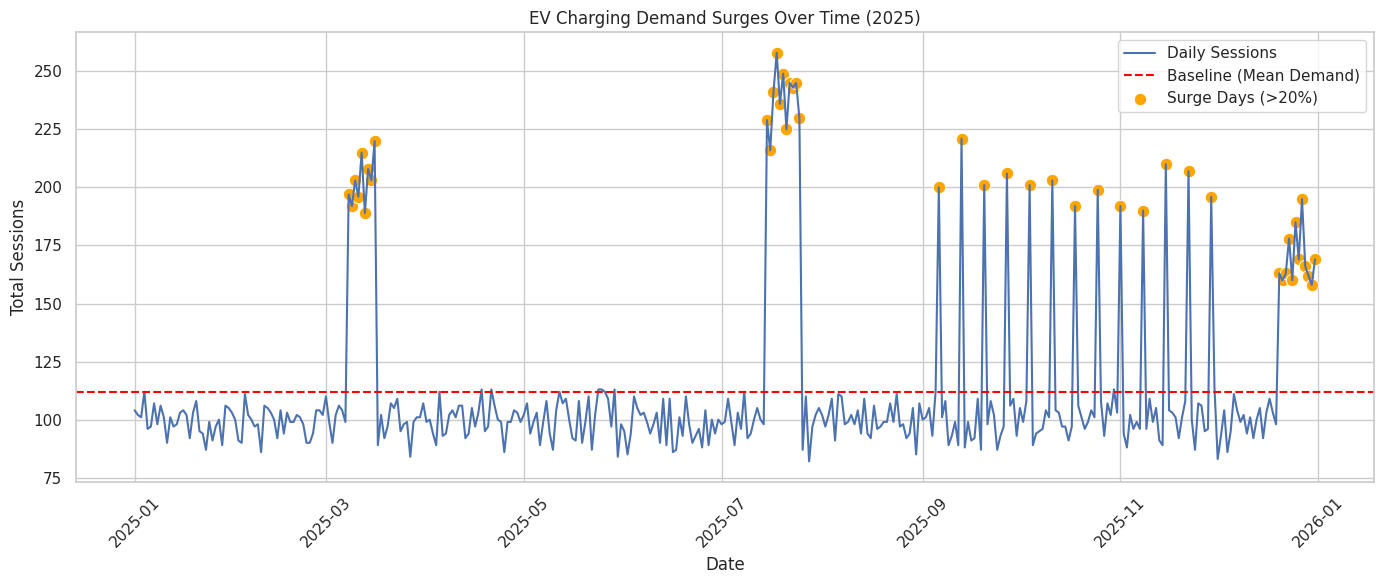

In [24]:
demand_df = demand.copy()

demand_df["date"] = pd.to_datetime(demand_df["date"])

daily_demand = demand_df.groupby("date").agg(
    total_sessions=("total_sessions", "sum"),
    total_kwh=("total_kwh_delivered", "sum"),
    revenue=("revenue_usd", "sum")
).reset_index()

baseline = daily_demand["total_sessions"].mean()

daily_demand["surge_pct"] = (
    (daily_demand["total_sessions"] - baseline) / baseline
) * 100

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=daily_demand,
    x="date",
    y="total_sessions",
    label="Daily Sessions"
)

plt.axhline(
    baseline,
    color="red",
    linestyle="--",
    label="Baseline (Mean Demand)"
)

# main surge points
surges = daily_demand[daily_demand["surge_pct"] > 20]

sns.scatterplot(
    data=surges,
    x="date",
    y="total_sessions",
    color="orange",
    s=80,
    label="Surge Days (>20%)"
)

plt.title("EV Charging Demand Surges Over Time (2025)")
plt.xlabel("Date")
plt.ylabel("Total Sessions")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Findings:**

To construct this graph, we first need to determine the metric of surge. For this graph, we chose to measure demand surges by the number of charging sessions each day, rather than kwh. This is because a few abnormally long sessions could distort the graph, as opposed to lots of sessions/traffic moving in and out of a station. When we plot the number of sessions across the year, we can see that demand surges at the start of March, the middle of July, and consistently throughout the rest of the year after September. To discern "baseline" demand with surges, we take the average number of sessions per day for the year, and use that as a reference.

---

## Question 2: The Vehicle Consolidation Problem

> After standardizing all vehicle ID variants, what is the true daily charging volume by vehicle type?

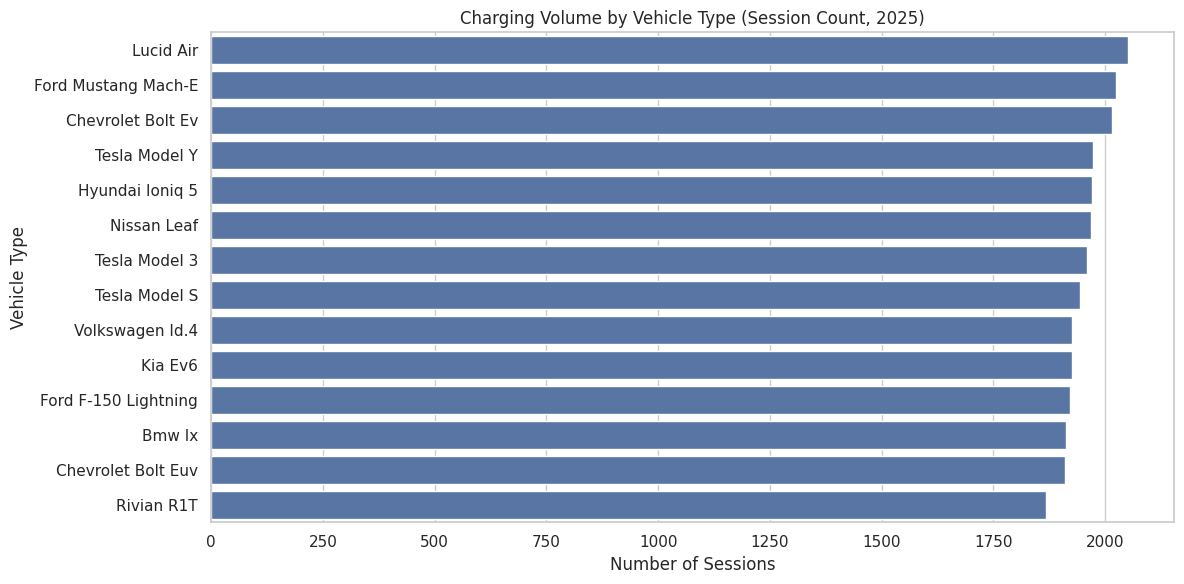

In [25]:
sessions_vehicles = sessions_clean.merge(
    vehicles_clean[["vehicle_id", "vehicle_name"]],
    on="vehicle_id",
    how="left"
)

# charging volume = session count
vehicle_volume = (
    sessions_vehicles.groupby("vehicle_name")
    .agg(session_count=("session_id", "count"))
    .reset_index()
    .sort_values("session_count", ascending=False)
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

sns.barplot(
    data=vehicle_volume,
    x="session_count",
    y="vehicle_name"
)

plt.title("Charging Volume by Vehicle Type (Session Count, 2025)")
plt.xlabel("Number of Sessions")
plt.ylabel("Vehicle Type")

plt.tight_layout()
plt.show()

**Findings:**

To visualize this, we can take our cleaned session data, join in our vehicles table to get our vehicle names, then aggregate our sessions by vehicle name and plot each of their total number of sessions to guage true charging volume. From the graph, we can see that the Lucid Air experienced the greatest number of charging sessions, followed by the Chevy Bolt Ev and the Tesla Model Y. One important thing to note is that there are many different variables affecting charging volume. The location of the chargers, Charlottesville, has an impact on the local EV makeup, as well as the option to charge at home, etc.

---

## Question 3: Weather and Grid Correlation

> How do temperature extremes correlate with daily charging demand and grid load?

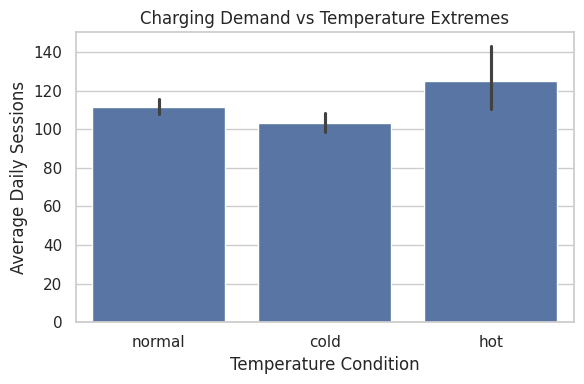

In [26]:
weather_df["temp_max_f"] = pd.to_numeric(weather_df["temp_max_f"])
weather_df["date"] = pd.to_datetime(weather_df["date"])

cold = weather_df["temp_max_f"].quantile(0.10)
hot = weather_df["temp_max_f"].quantile(0.90)

def label_temp(x):
    if x <= cold:
        return "cold"
    elif x >= hot:
        return "hot"
    else:
        return "normal"

demand_df["date"] = pd.to_datetime(demand_df["date"])

daily_demand = demand_df.groupby("date").agg(
    total_sessions=("total_sessions", "sum"),
    total_kwh=("total_kwh_delivered", "sum")
).reset_index()

daily_demand["date"] = pd.to_datetime(daily_demand["date"])

demand_weather = daily_demand.merge(
    weather_df,
    on="date",
    how="inner"
)

demand_weather["temp_extreme"] = demand_weather["temp_max_f"].apply(label_temp)

summary = demand_weather.groupby("temp_extreme").agg(
    avg_sessions=("total_sessions", "mean"),
    avg_kwh=("total_kwh", "mean"),
    count_days=("date", "count")
).reset_index()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))

sns.barplot(
    data=demand_weather,
    x="temp_extreme",
    y="total_sessions",
    estimator="mean"
)

plt.title("Charging Demand vs Temperature Extremes")
plt.xlabel("Temperature Condition")
plt.ylabel("Average Daily Sessions")

plt.tight_layout()
plt.show()

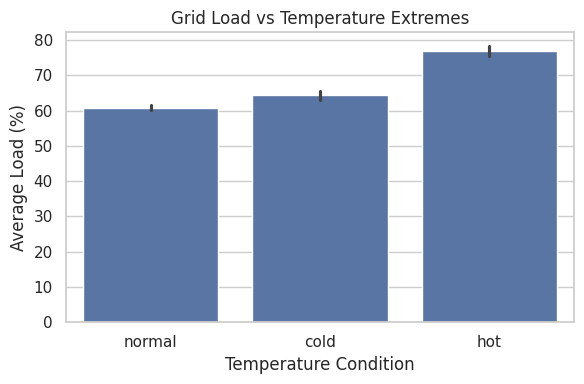

In [27]:
grid_df = grid.copy()

grid_df["temperature_high_f"] = pd.to_numeric(grid_df["temperature_high_f"])

cold = grid_df["temperature_high_f"].quantile(0.10)
hot = grid_df["temperature_high_f"].quantile(0.90)

def label_temp(x):
    if x <= cold:
        return "cold"
    elif x >= hot:
        return "hot"
    else:
        return "normal"

grid_df["temp_extreme"] = grid_df["temperature_high_f"].apply(label_temp)

grid_summary = grid_df.groupby("temp_extreme").agg(
    avg_load_pct=("load_pct", "mean"),
    avg_capacity=("available_capacity_mw", "mean"),
    outage_rate=("outage_flag", "mean")
).reset_index()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))

sns.barplot(
    data=grid_df,
    x="temp_extreme",
    y="load_pct",
    estimator="mean"
)

plt.title("Grid Load vs Temperature Extremes")
plt.xlabel("Temperature Condition")
plt.ylabel("Average Load (%)")

plt.tight_layout()
plt.show()

**Findings:**

To answer this question, we can split our analysis into two different graphs, one showcasing the relationship of temperature extremes with daily charging demand, and the other with grid load. For the former, we gather our temperature data by using the OpenMeteo data we pulled from the API, joining it with our demand df. We define "cold" and "hot" temperatures as anything that fall beyond the 0.10 and 0.90 quantiles, respectively. Then, we aggregate demand by date to get the session volume across all stations on a given day, and combine this with out weather data. Using our quantiles, we can label a given day as "cold", "hot", or "normal", and plot each of the counts for each day. Interestingly, we can see that "hot" days see the most charging sessions, while "cold" days see the least.

A similar process can be followed for our second visualization, only this time we use the temperature data embedded within the grid df. We still label each day as usual and reach a very interesting conclusion. Essentially, both "hot" and "cold" days use more load than "normal" days. This implies a correlation between temperature extremes and grid load.

---

## Question 4: Station-Level Geographic Patterns

> Do all stations experience the same usage patterns?

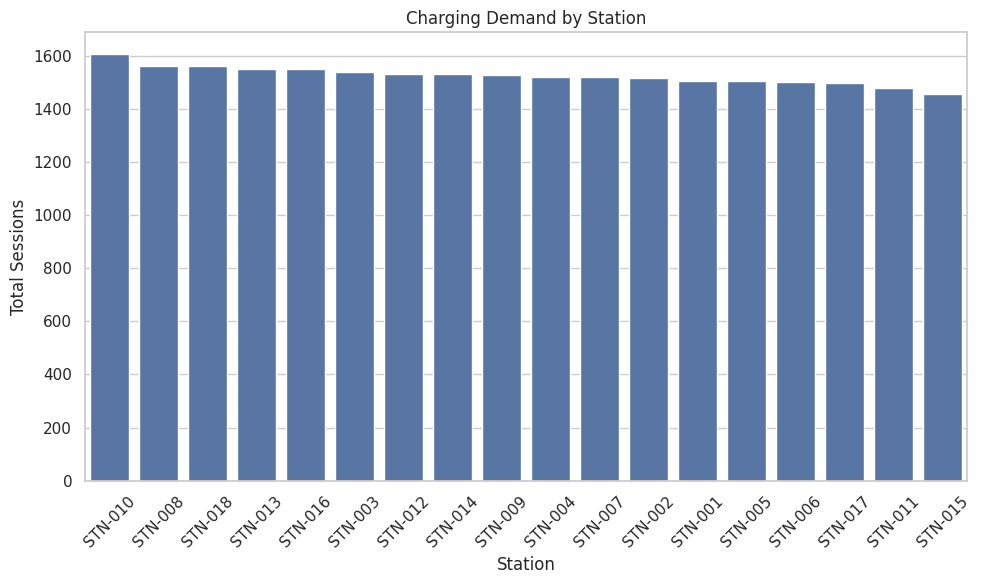

,station_id,station_name,city,state,zip_code,latitude,longitude,region
0,STN-001,Downtown Charging Hub,Charlottesville,VA,22902,38.0293,-78.4767,CENTRAL
1,STN-002,University Ave Station,Charlottesville,VA,22903,38.0336,-78.5080,CENTRAL
2,STN-003,Pantops Charging Plaza,Charlottesville,VA,22911,38.0280,-78.4490,EAST
3,STN-004,Barracks Road Station,Charlottesville,VA,22903,38.0440,-78.5070,WEST
4,STN-005,Rivanna Station,Charlottesville,VA,22911,38.0520,-78.4430,EAST
5,STN-006,5th Street Hub,Charlottesville,VA,22902,38.0200,-78.4880,CENTRAL
6,STN-007,Rio Road Charging,Charlottesville,VA,22901,38.0700,-78.4800,NORTH
7,STN-008,Hydraulic Rd Station,Charlottesville,VA,22901,38.0560,-78.4990,NORTH
8,STN-009,Seminole Trail Plaza,Charlottesville,VA,22901,38.0800,-78.4850,NORTH
9,STN-010,Avon Street Hub,Charlottesville,VA,22902,38.0100,-78.4750,SOUTH


In [28]:
station_usage = sessions_clean.groupby("station_id").agg(
    total_sessions=("session_id", "count"),
    total_kwh=("kwh_delivered", "sum"),
    avg_session_duration=("session_end", lambda x: 0),
    avg_cost=("cost_usd", "mean")
).reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=station_usage.sort_values("total_sessions", ascending=False),
    x="station_id",
    y="total_sessions"
)

plt.title("Charging Demand by Station")
plt.xlabel("Station")
plt.ylabel("Total Sessions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

stations_clean

**Findings:**

To answer this question, we can determine usage patterns by analyzing the number of charging sessions each station receives across the year. When plotting this, we can see that station 10, Avon Street Hub, receives the greatest number of charging sessions, while station 15, Route 29 North Hub, receives the least number of charging sessions. It is important to note that, across all stations, there is still a relatively stable distribution of number of sessions. In other words, there are no outliers, and it appears that all of our stations experience similar usage patterns.

---

## Question 5: The Connector Type Investigation

> Is the CHAdeMO decline real, or a data artifact?

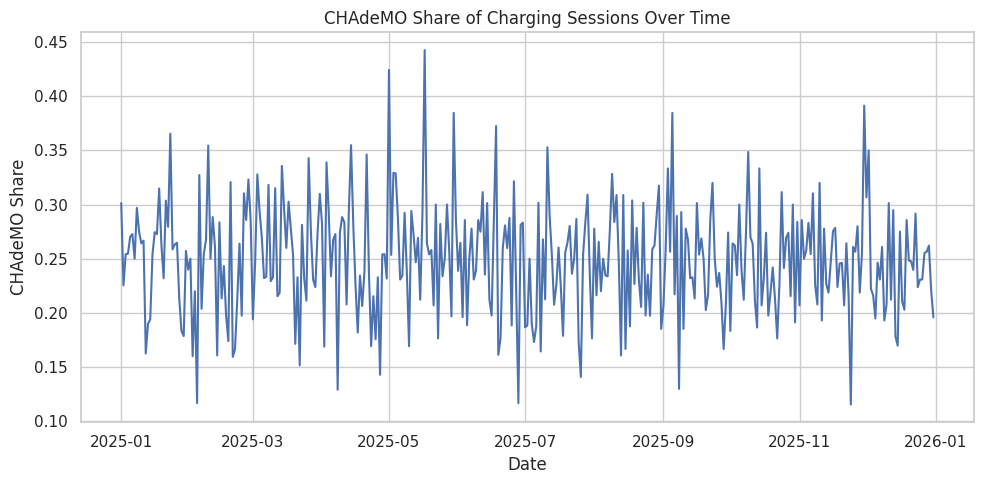

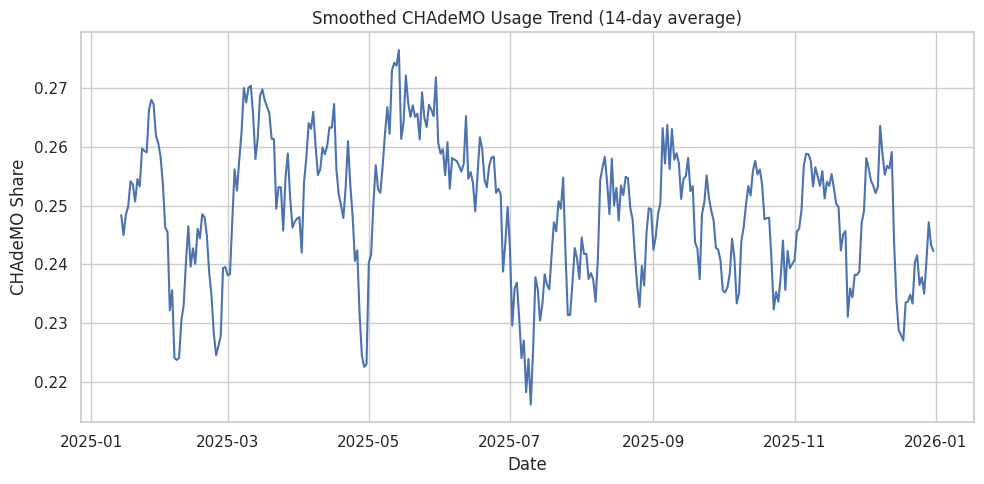

In [29]:
sessions_clean["is_chademo"] = sessions_clean["connector_used"].str.contains("CHADEMO")

sessions_clean["date"] = pd.to_datetime(sessions_clean["date"])

daily_chademo = sessions_clean.groupby("date").agg(
    chademo_sessions=("is_chademo", "sum"),
    total_sessions=("session_id", "count")
).reset_index()

daily_chademo["chademo_share"] = (
    daily_chademo["chademo_sessions"] / daily_chademo["total_sessions"]
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

sns.lineplot(
    data=daily_chademo,
    x="date",
    y="chademo_share"
)

plt.title("CHAdeMO Share of Charging Sessions Over Time")
plt.ylabel("CHAdeMO Share")
plt.xlabel("Date")

plt.tight_layout()
plt.show()

daily_chademo["rolling_share"] = daily_chademo["chademo_share"].rolling(14).mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=daily_chademo,
    x="date",
    y="rolling_share"
)

plt.title("Smoothed CHAdeMO Usage Trend (14-day average)")
plt.ylabel("CHAdeMO Share")
plt.xlabel("Date")

plt.tight_layout()
plt.show()

**Findings:**

To answer this question, we can start by labeling each session with a boolean flag of whether the connecter used is CHAdeMO or not. Then, we can aggregate our sessions by date and compute how many sessions per day used CHAdeMO, plotting this share across the year to see its change over time. To take it one step further, we can compute the rolling 14-day average of its usage, allowing for an easier to analyze line chart that looks past the unimportant details. Looking at both graphs, we can see that there does not appear to be a steady decline in the usage of CHAdeMO connectors. In fact, both line charts show usage hovering between 22-27% throughout the year, with usage peaking in early May and dropping by early July. Our data suggest that the CHAdeMO decline is but a data artifact.

---

## Cloud Upload

Upload your cleaned data back to your team folder in GCS.

In [30]:
# save all cleaned files as csv files
sessions_clean.to_csv("cleaned_sessions.csv", index=False)
stations_clean.to_csv("cleaned_stations.csv", index=False)
vehicles_clean.to_csv("cleaned_vehicles.csv", index=False)
operators_clean.to_csv("cleaned_operators.csv", index=False)
grid.to_csv("cleaned_grid.csv", index=False)
demand.to_csv("cleaned_demand.csv", index=False)


In [31]:
# Upload cleaned files to GCS

def upload_to_gcs(source_file, destination_blob):
    blob = bucket.blob(destination_blob)
    blob.upload_from_filename(source_file)
    print("Uploaded.")

upload_to_gcs(
    source_file="cleaned_sessions.csv",
    destination_blob=f"{TEAM}/cleaned_sessions.csv"
)

upload_to_gcs(
    source_file="cleaned_stations.csv",
    destination_blob=f"{TEAM}/cleaned_stations.csv"
)

upload_to_gcs(
    source_file="cleaned_vehicles.csv",
    destination_blob=f"{TEAM}/cleaned_vehicles.csv"
)

upload_to_gcs(
    source_file="cleaned_operators.csv",
    destination_blob=f"{TEAM}/cleaned_operators.csv"
)

upload_to_gcs(
    source_file="cleaned_grid.csv",
    destination_blob=f"{TEAM}/cleaned_grid.csv"
)

upload_to_gcs(
    source_file="cleaned_demand.csv",
    destination_blob=f"{TEAM}/cleaned_demand.csv"
)


Uploaded.
Uploaded.
Uploaded.
Uploaded.
Uploaded.
Uploaded.


---

## Reflection

### 1. Data Quality Impact
We realized that data quality issues had a much bigger impact on our results than we initially expected. Missing values, inconsistent timestamps, and duplicate entries would sometimes distort trends or make patterns look more significant (or less significant) than they actually were (for instance, looking at total charging volume by vehicle). Once we spent time cleaning and standardizing the data, our analysis became noticeably more stable and interpretable. It made us appreciate how much of data work is really about getting the dataset into a trustworthy state before doing any actual analysis.

### 2. Cloud Pipeline Experience
Working with a cloud pipeline changed our approach to data workflows. Instead of everything living locally, we had to think more about structure, storage, and how different parts of the pipeline connect. Uploading processed data to GCP made it easier to reuse and query later, especially when working with larger datasets. The setup process (authentication, bucket configuration, etc.) was a bit frustrating at first, but once it was working, the pipeline felt much more scalable and “real-world” compared to local scripts, which was very rewarding.

### 3. ETL Trade-offs
We ran into several trade-offs while designing our ETL process. When we did more transformations upfront, our later analysis became faster and cleaner, but it also made the pipeline more complex and slightly slower to run initially, especially for tables with tens of thousands of rows. On the other hand, keeping transformations minimal made things simpler but pushed more work into the analysis stage. We ended up realizing that it’s better to do consistent, reusable cleaning early in the pipeline, even if it takes more time upfront, because it prevents repeated errors later.

### 4. Pipeline Trust
Building trust in our pipeline took intentional effort. We didn’t fully trust the output right away. We often validated each step by checking schema consistency, looking at summary statistics, and manually inspecting samples before and after transformations. Over time, as we added more checks and logging, we became more confident that the pipeline was producing reliable results. Still, we’ve learned that trust in data pipelines is something you continuously earn, not something you assume.

### 5. Team Collaboration
Working with others on the pipeline helped us realize how important communication is in data projects. Even small misunderstandings about column definitions or preprocessing steps could lead to mismatched results. Using version control and documenting decisions made collaboration much smoother, especially when merging different parts of the pipeline. We also found that discussing design choices early saved a lot of time later because we avoided redundant or conflicting work. This was a great experience overall!